In [182]:
from koala.voronization import generate_lattice
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import example_graphs as eg
from koala.lattice import Lattice
from koala.graph_color import color_lattice
from koala import plotting as pl
from tqdm import tqdm


from copy import copy
import numpy as np
import matplotlib.pyplot as plt

In [183]:
def energies(t1, t2, Jc, m, k):
    ar = np.array(
        [
            -2 * t1 * np.cos(k[0]) - 2 * t2 * np.cos(k[1]) - Jc * m,
            -2 * t1 * np.cos(k[0]) - 2 * t2 * np.cos(k[1]) + Jc * m,
            -2 * t1 * np.cos(k[1]) - 2 * t2 * np.cos(k[0]) + Jc * m,
            -2 * t1 * np.cos(k[1]) - 2 * t2 * np.cos(k[0]) - Jc * m,
        ]
    )
    return ar


m_contributions = np.array([1, -1, -1, 1])

kx_walk = np.concatenate(
    [
        np.linspace(0, 0, 100),
        np.linspace(0, np.pi, 100),
        np.linspace(np.pi, np.pi, 100),
        np.linspace(np.pi, 0, 100),
    ]
)

ky_walk = np.concatenate(
    [
        np.linspace(0, np.pi, 100),
        np.linspace(np.pi, np.pi, 100),
        np.linspace(np.pi, 0, 100),
        np.linspace(0, 0, 100),
    ]
)

k_walk = np.array([kx_walk, ky_walk]).T


In [184]:
t1 = 2
t2 = 0.5
Jc = 2.5
m = 2

filling = 0.5
k_resolution = 500

kx = np.linspace(-np.pi, np.pi, k_resolution, endpoint=False)
ky = np.linspace(-np.pi, np.pi, k_resolution, endpoint=False)

kx, ky = np.meshgrid(kx, ky)

100%|██████████| 400/400 [00:00<00:00, 95826.00it/s]

Fermi level: 0.0


(2, 0.5, 2.5, 2)

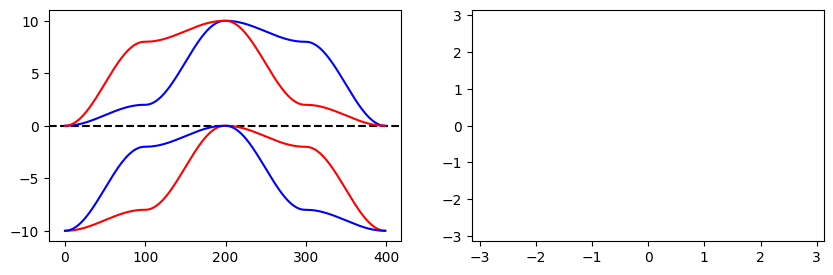

In [185]:
energies_walk = np.array([energies(t1, t2, Jc, m, k) for k in tqdm(k_walk)])
energy_values = energies(t1, t2, Jc, m, np.array([kx, ky]))
colours = ["r", "b", "r", "b"]

fermi_level = np.percentile(energy_values, 100 * filling)
print(f"Fermi level: {fermi_level}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].axhline(fermi_level, color="k", linestyle="--")
for i in range(4):
    ax[0].plot(energies_walk[:, i], color=colours[i])
    ax[1].contour(kx, ky, energy_values[i], levels=[fermi_level], colors=colours[i])

t1, t2, Jc, m

100%|██████████| 400/400 [00:00<00:00, 174817.30it/s]


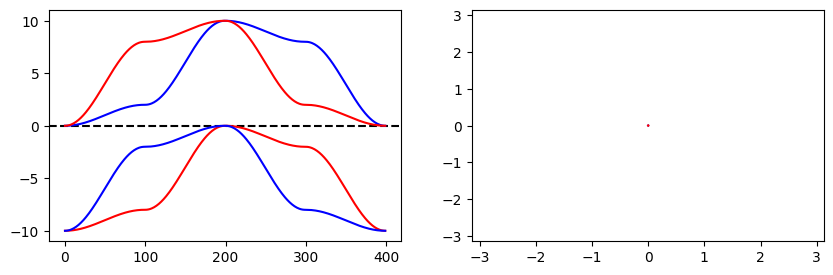

In [186]:
new_m = m

for x in range(20):
    new_energy_values = energies(t1, t2, Jc, new_m, np.array([kx, ky]))
    fermi_level = np.percentile(new_energy_values, 100 * filling)
    new_m = (
        np.mean(m_contributions[:, None, None] * (new_energy_values < fermi_level)) * 4
    )
    # print(new_m)

new_energies_walk = np.array([energies(t1, t2, Jc, new_m, k) for k in tqdm(k_walk)])
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].axhline(fermi_level, color="k", linestyle="--")
for i in range(4):
    ax[0].plot(new_energies_walk[:, i], color=colours[i])
    ax[1].contour(kx, ky, new_energy_values[i], levels=[fermi_level], colors=colours[i])

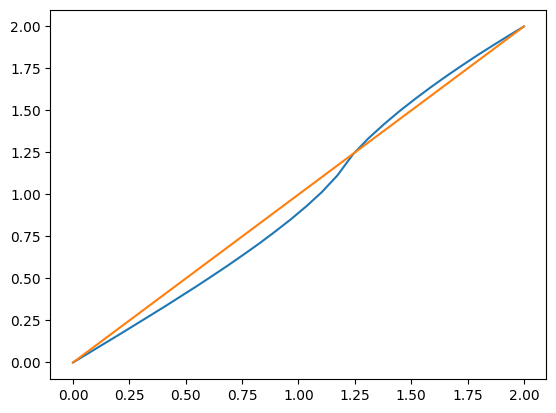

In [187]:
Jc = 2.5
s_out = []
for m in np.linspace(0, 2, 30):
    new_energy_values = energies(t1, t2, Jc, m, np.array([kx, ky]))
    fermi_level = np.percentile(new_energy_values, 100 * filling)
    new_m = (
        np.mean(m_contributions[:, None, None] * (new_energy_values < fermi_level)) * 4
    )
    s_out.append(new_m)

plt.plot(np.linspace(0, 2, 30), s_out)
plt.plot(np.linspace(0, 2, 30), np.linspace(0, 2, 30))
